<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/Implementing_Regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Linear Regression

**Y = Wx + b**

`--->W = Weights`

`--->x = data points`

`--->b = bias`

### Gradient Descent

`w = w - a*dw`

`b = b - a*db`

a = This is called the learning rate , it tell how much step we want to move so as to attain the minimum global minimum loss function.

The folowing give the gradient for the parameter (slopes) and the bias(intercept)

$$dw = -\frac{2}{n} \sum_{i=1}^{n} x_i(y_i - y_{\text{pred}})$$


$$db = -\frac{2}{n} \sum_{i=1}^{n} (y_i - y_{\text{pred}})$$


In [ ]:
import numpy as np

In [ ]:
class LinearRegression:


    def __init__(self, lr, iters):
        # Define the learning rate and the iterations
        self.lr = lr
        self.iters = iters
        self.w = None
        self.b = 0

    def fit(self, X, Y):

        self.n_samples, self.feats = X.shape # Exctract the datapoints(number of samples) and features(Rows and colums)
        self.w = np.zeros(self.feats) # initialize the weights

        self.X = X
        self.Y = Y

        for i in range(self.iters):
            self.update_weights()


    def update_weights(self):
        y_predict = self.predicts(self.X)

        dw = -(2 * (self.X.T).dot(self.Y - y_predict)) / self.n_samples
        db = - 2 * np.sum(self.Y - y_predict) / self.n_samples

        #Update the weights and biase
        self.w -= (self.lr * dw)
        self.b -= (self.lr * db)

    def predicts(self, X):
        return X.dot(self.w) + self.b


In [ ]:
# Using the linear Regression to predcit
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("salary.csv")

In [ ]:
# Print the first five row
df.head()

,yearsOfExperience,salaryExpectation
0,0.0,45000
1,0.5,48000
2,1.0,52000
3,1.5,55000
4,2.0,60000


In [ ]:
# Print the last five row
df.tail()

,yearsOfExperience,salaryExpectation
31,21.0,155000
32,22.0,160000
33,23.0,165000
34,24.0,168000
35,25.0,170000


In [ ]:
#Print the dimension of the data
df.shape

(36, 2)

In [ ]:
# Check or any null or empty value
df.isnull().sum()

yearsOfExperience    0
salaryExpectation    0
dtype: int64

In [ ]:
#Extract each data i.e separate the targets from the training features
X = df.iloc[:, :-1].values
Y = df.iloc[:, 1].values

In [ ]:
#Split the test data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state= 2)

### Training the Linear Regression

In [ ]:
model = LinearRegression(lr=0.002, iters=1000)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
#Print the weight and bias
print("weight = ", model.w[0])
print("bias = ", model.b)

weight =  5711.746457728907
bias =  42413.32567395155


**From the linear regression equestion**

`Y = Wx + b`

`salary = 5711(experience) - 42413 `

In [ ]:
#Run prediction on the test data
test_predicted_data = model.predicts(X_test)
print(test_predicted_data)

[ 76683.80442033  79539.67764919 145224.76191307 156648.25482853
 122377.77608216  68116.18473373 139513.01545534  42413.32567395
 128089.52253989  82395.55087805  45269.19890282  88107.29733578]


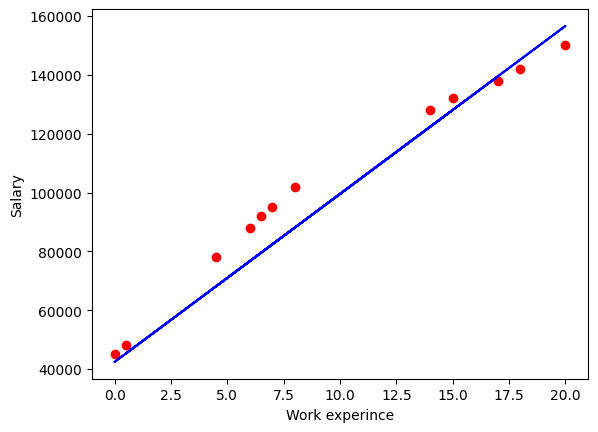

In [ ]:
plt.scatter(X_test, y_test, color="red")
plt.plot(X_test, test_predicted_data, color="blue")
plt.xlabel("Work experince")
plt.ylabel("Salary")
plt.show();

## Normalisation of The Data

In [ ]:
#Build a normalize function
def norm_features(X):
    #get the mean
    X_mean = np.mean(X, axis=0)
    # Standard deviation
    X_std = np.std(X, axis=0)
    #Avoid zero division
    X_std[X_std == 0] = 1
    X_norm = (X - X_mean) / X_std
    return X_mean, X_std, X_norm

In [ ]:
#Normalise the training data
X_mean, X_std, X_norm = norm_features(X_train)

In [ ]:
model = LinearRegression(lr=0.001, iters=1000)
model.fit(X_norm, y_train)

In [ ]:
#Normalise test data as well
X_test_norm = (X_test - X_mean) / X_std
prediction_data = model.predicts(X_test_norm)
prediction_data

array([ 74314.083031  ,  76395.03678691, 124256.97317278, 132580.7881964 ,
       107609.34312552,  68071.22176328, 120095.06566096,  49342.63796012,
       111771.25063733,  78475.99054282,  51423.59171602,  82637.89805463])

In [ ]:
print("weights = ", model.w[0])
print("bias = ", model.b)

weights =  32097.6530154448
bias =  94169.85011861734


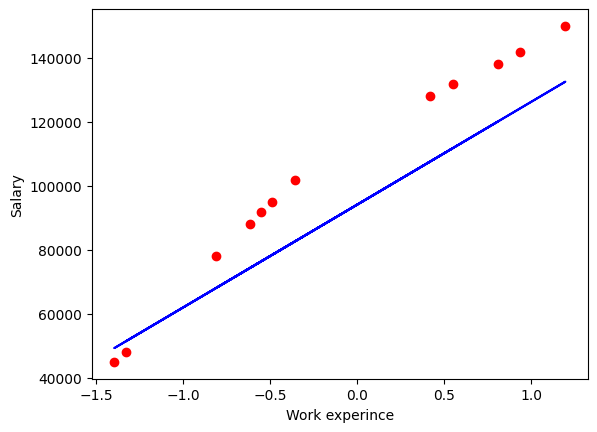

In [ ]:
plt.scatter(X_test_norm, y_test, color="red")
plt.plot(X_test_norm, prediction_data, color="blue")
plt.xlabel("Work experince")
plt.ylabel("Salary")
plt.show();

From this graph, It can be deduced that normalization does not really apply when we consider
the work experince. Infact it worsen the model prediction. Althought it can be very useful when considering multiple features